In [2]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

# 정규화
train_scaled = train_input / 255.0

# train과 valid data 생성
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [3]:
# Model 함수
def model_fn(a_layer = None):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=((28, 28))))
    model.add(keras.layers.Dense(100, activation='relu'))
    if a_layer:
        model.add(a_layer)
    model.add(keras.layers.Dense(10, activation='softmax')) # 이진분류만 SIGMOID
    return model

In [15]:
# 모델 구성 및 Summary
model = model_fn()
model.summary()

/opt/anaconda3/envs/deep_env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# 훈련 및 과정에 대한 history 보기
model.compile ( # 손실함수
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 695us/step - accuracy: 0.8107 - loss: 0.5310
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 683us/step - accuracy: 0.8588 - loss: 0.3932
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 677us/step - accuracy: 0.8728 - loss: 0.3558
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step - accuracy: 0.8805 - loss: 0.3339
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step - accuracy: 0.8873 - loss: 0.3159


In [ ]:
history.history.keys() # 정확도, 손실함수(문제와 정답이 얼마나 차이나는지)

dict_keys(['accuracy', 'loss'])

#### 손실곡선

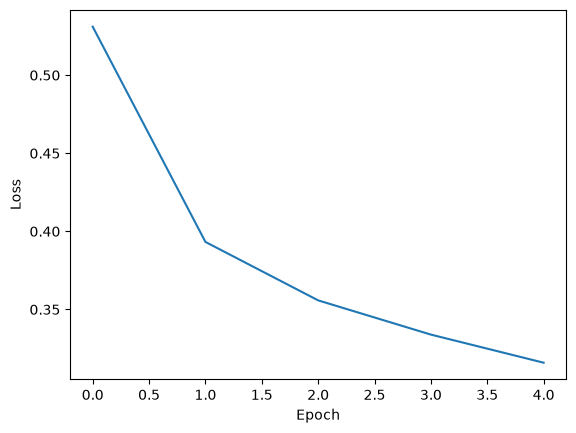

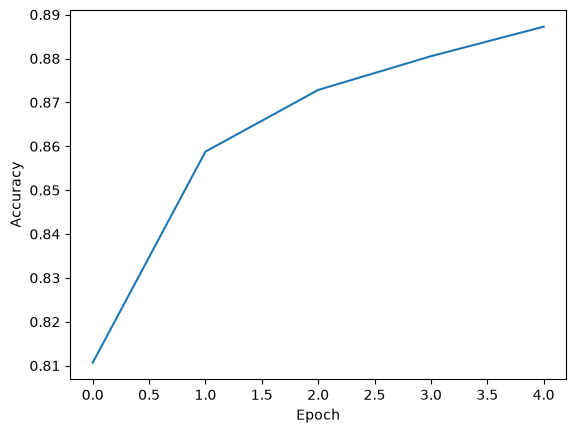

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history.history['accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

epochs를늘리면 정확도가 더 올라가고 손실이 더 떨어질 것 같음(가정)

#### 반복 훈련의 증가(epochs 증가)

In [30]:
model = model_fn()
model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=20
)

Epoch 1/20


/opt/anaconda3/envs/deep_env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 734us/step - accuracy: 0.8109 - loss: 0.5322
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 731us/step - accuracy: 0.8576 - loss: 0.3936
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step - accuracy: 0.8720 - loss: 0.3558
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step - accuracy: 0.8786 - loss: 0.3343
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 690us/step - accuracy: 0.8864 - loss: 0.3183
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - accuracy: 0.8911 - loss: 0.3044
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - accuracy: 0.8935 - loss: 0.2955
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 683us/step - accuracy: 0.8983 - loss: 0.2867
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step - accuracy: 0.9010 - loss: 0.2794
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step - accuracy: 0.9043 - loss: 0.2726
Epoch 11/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 713us/step - accuracy: 0.9055 - loss: 0.2656
Epoch 12/20
1500/15

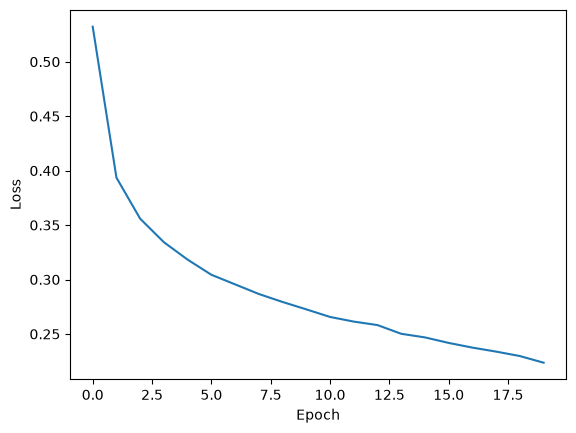

In [33]:
# history의 시각화
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

#### 검증손실
:검증세트 대한 정확도를 파악

In [34]:
model = model_fn()
model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history= model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data= (val_scaled, val_target)
)

Epoch 1/20


/opt/anaconda3/envs/deep_env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 883us/step - accuracy: 0.8145 - loss: 0.5301 - val_accuracy: 0.8546 - val_loss: 0.4131
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step - accuracy: 0.8597 - loss: 0.3917 - val_accuracy: 0.8607 - val_loss: 0.3847
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 807us/step - accuracy: 0.8733 - loss: 0.3529 - val_accuracy: 0.8785 - val_loss: 0.3508
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step - accuracy: 0.8807 - loss: 0.3355 - val_accuracy: 0.8709 - val_loss: 0.3577
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 823us/step - accuracy: 0.8868 - loss: 0.3156 - val_accuracy: 0.8799 - val_loss: 0.3549
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step - accuracy: 0.8896 - loss: 0.3048 - val_accuracy: 0.8808 - val_loss: 0.3574
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - accuracy: 0.8948 - loss: 0.2952 - val_accuracy: 0.8763 - val_loss: 0.3708
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - accuracy: 0.8974 - loss: 0.28

In [35]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

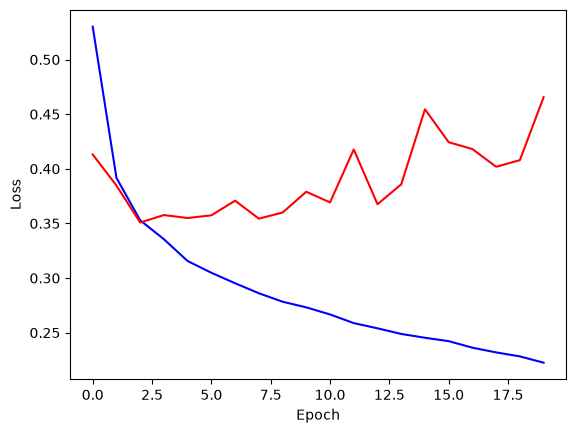

In [39]:
# history의 시각화
plt.plot(history.history['loss'], color='blue')
plt.plot(history.history['val_loss'], color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

- 훈련세트는 epochs가 증가됨에 따라 손실이 떨어지고 있으나,
- 검증세트는 epochs가 증가됨에 따라 초반에는 손실이 떨어지나 진행하면 할 수록 손실율 증가 
- 이 모델은 훈련의 정확도가 높아 검증에는 적합하지 않은 과대적합 모델이다.

In [ ]:
# 옵티마이저 사용
model = model_fn()
model.compile(
    # 모델 학습 과정에서 오차(Loss)를 줄이기 위해 파라미터(가중치)를 올바른 방향으로 갱신하는 최적화 알고리즘
    optimizer = 'adam', 
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history= model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data= (val_scaled, val_target)
)

Epoch 1/20


/opt/anaconda3/envs/deep_env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8180 - loss: 0.5197 - val_accuracy: 0.8382 - val_loss: 0.4582
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - accuracy: 0.8612 - loss: 0.3932 - val_accuracy: 0.8668 - val_loss: 0.3735
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 996us/step - accuracy: 0.8728 - loss: 0.3496 - val_accuracy: 0.8622 - val_loss: 0.3754
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 915us/step - accuracy: 0.8820 - loss: 0.3243 - val_accuracy: 0.8623 - val_loss: 0.3685
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step - accuracy: 0.8868 - loss: 0.3061 - val_accuracy: 0.8812 - val_loss: 0.3279
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 886us/step - accuracy: 0.8933 - loss: 0.2882 - val_accuracy: 0.8808 - val_loss: 0.3335
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.8962 - loss: 0.2796 - val_accuracy: 0.8840 - val_loss: 0.3236
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 916us/step - accuracy: 0.8991 - loss: 0.2680

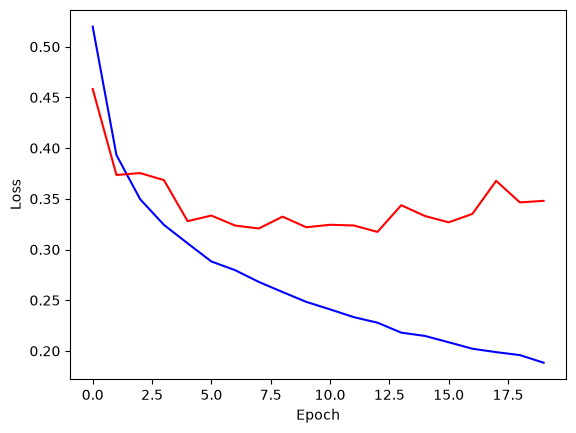

In [41]:
# history의 시각화
plt.plot(history.history['loss'], color='blue')
plt.plot(history.history['val_loss'], color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

- optimizar(최적화 알고리즘)을 사용해서 train과 valid의 손실율이 조금 더 비슷해지고 
- valid의 손실율이 안정화 되었으나, 아직 과대적합이다.
- 규제: 과대적합을 방지하기 위해 훈련세트를 덜 훈련시킴

#### Dropout
: 훈련시 각 데이터를 처리할 때 데이터의 갯수를 랜덤으로 줄인다.

In [49]:
# model에 dropout 추가
model = model_fn(keras.layers.Dropout(0.3))
model.summary()

model.compile(
    optimizer = 'adam', 
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history= model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data= (val_scaled, val_target)
)

/opt/anaconda3/envs/deep_env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7911 - loss: 0.5938 - val_accuracy: 0.8437 - val_loss: 0.4356
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 980us/step - accuracy: 0.8395 - loss: 0.4453 - val_accuracy: 0.8626 - val_loss: 0.3778
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 946us/step - accuracy: 0.8522 - loss: 0.4094 - val_accuracy: 0.8661 - val_loss: 0.3795
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 953us/step - accuracy: 0.8590 - loss: 0.3851 - val_accuracy: 0.8657 - val_loss: 0.3698
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - accuracy: 0.8642 - loss: 0.3696 - val_accuracy: 0.8712 - val_loss: 0.3473
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 899us/step - accuracy: 0.8695 - loss: 0.3538 - val_accuracy: 0.8743 - val_loss: 0.3453
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step - accuracy: 0.8721 - loss: 0.3465 - val_accuracy: 0.8775 - val_loss: 0.3321
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 989us/step - accuracy: 0.8755 - l

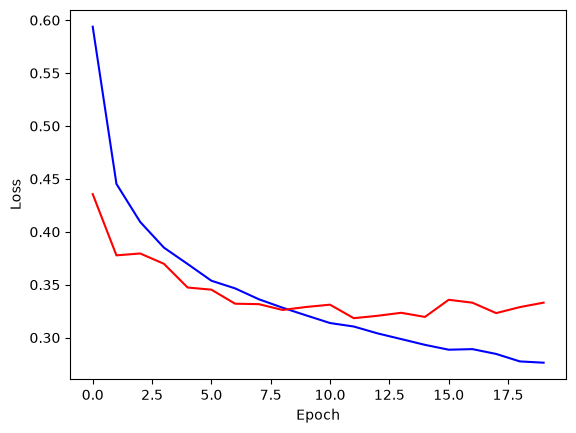

In [50]:
# history의 시각화
plt.plot(history.history['loss'], color='blue')
plt.plot(history.history['val_loss'], color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show() # train이 valid보다 loss가 낮아야 함

epochs가 9일 경우 train과 valid의 차이가 적은 것 같다.
기본적으로 훈련의 손실이 검증보다 적게 나오는 epochs를 선택

In [51]:
# model에 dropout 추가
model = model_fn(keras.layers.Dropout(0.3))
model.summary()

model.compile(
    optimizer = 'adam', 
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history= model.fit(
    train_scaled,
    train_target,
    epochs=9,
    validation_data= (val_scaled, val_target)
)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7928 - loss: 0.5868 - val_accuracy: 0.8447 - val_loss: 0.4320
Epoch 2/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 886us/step - accuracy: 0.8426 - loss: 0.4378 - val_accuracy: 0.8568 - val_loss: 0.3899
Epoch 3/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - accuracy: 0.8532 - loss: 0.4016 - val_accuracy: 0.8584 - val_loss: 0.3798
Epoch 4/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 917us/step - accuracy: 0.8614 - loss: 0.3789 - val_accuracy: 0.8741 - val_loss: 0.3521
Epoch 5/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 890us/step - accuracy: 0.8659 - loss: 0.3666 - val_accuracy: 0.8753 - val_loss: 0.3457
Epoch 6/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 973us/step - accuracy: 0.8694 - loss: 0.3533 - val_accuracy: 0.8673 - val_loss: 0.3637
Epoch 7/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step - accuracy: 0.8748 - loss: 0.3382 - val_accuracy: 0.8753 - val_loss: 0.3482
Epoch 8/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.8784 - loss: 0.3

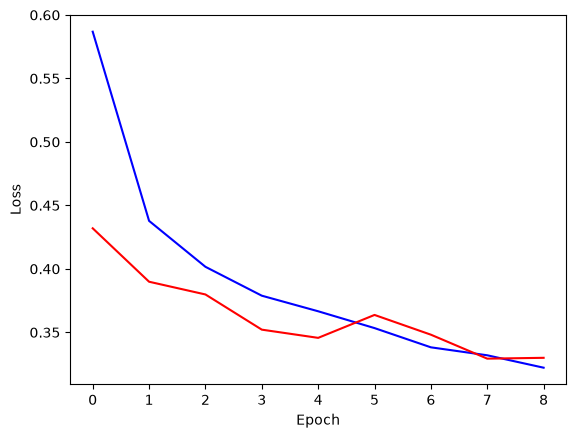

In [52]:
# history의 시각화
plt.plot(history.history['loss'], color='blue')
plt.plot(history.history['val_loss'], color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show() # train이 valid보다 loss가 낮아야 함

#### 모델의 저장과 복원

In [55]:
model.save('data/model_fashion.keras')

In [57]:
# 복원
model1 = keras.models.load_model('data/model_fashion.keras')

In [58]:
model1.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - accuracy: 0.8834 - loss: 0.3299


[0.3299344480037689, 0.8834166526794434]

#### Callbacks
: 훈련 수행 시 손실값이 가장 작은 친구를 저장

In [59]:
# model에 dropout 추가
model = model_fn(keras.layers.Dropout(0.3))
model.summary()

model.compile(
    optimizer = 'adam', 
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('data/best_model.keras')

history= model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data= (val_scaled, val_target),
    callbacks = [checkpoint_cb]
)

/opt/anaconda3/envs/deep_env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 984us/step - accuracy: 0.7910 - loss: 0.5895 - val_accuracy: 0.8450 - val_loss: 0.4246
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 906us/step - accuracy: 0.8427 - loss: 0.4387 - val_accuracy: 0.8577 - val_loss: 0.3874
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 912us/step - accuracy: 0.8533 - loss: 0.4043 - val_accuracy: 0.8563 - val_loss: 0.3831
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 911us/step - accuracy: 0.8615 - loss: 0.3800 - val_accuracy: 0.8677 - val_loss: 0.3594
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 922us/step - accuracy: 0.8665 - loss: 0.3674 - val_accuracy: 0.8691 - val_loss: 0.3563
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 913us/step - accuracy: 0.8710 - loss: 0.3528 - val_accuracy: 0.8722 - val_loss: 0.3467
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - accuracy: 0.8734 - loss: 0.3437 - val_accuracy: 0.8802 - val_loss: 0.3373
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step - accuracy: 0.8770 -

In [ ]:
model_best = keras.models.load_model('data/best_model.keras')
model_best.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - accuracy: 0.8833 - loss: 0.3247


[0.324695348739624, 0.8833333253860474]

#### Early-Stopping(조기종료)
: Callbacks를 끝까지 기다리는 것이 아니라 patience(Hyper parameter)을 선정하여 한계값을 실행한다.

In [5]:
# model에 dropout 추가
model = model_fn(keras.layers.Dropout(0.3))
model.summary()

model.compile(
    optimizer = 'adam', 
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('data/best_model.keras')
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2, # 떨어짐 횟수를 2번까지 참아줌
    restore_best_weights=True
) 

history= model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data= (val_scaled, val_target),
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 968us/step - accuracy: 0.7912 - loss: 0.5874 - val_accuracy: 0.8437 - val_loss: 0.4253
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - accuracy: 0.8430 - loss: 0.4375 - val_accuracy: 0.8620 - val_loss: 0.3825
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 916us/step - accuracy: 0.8549 - loss: 0.4008 - val_accuracy: 0.8654 - val_loss: 0.3778
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step - accuracy: 0.8629 - loss: 0.3806 - val_accuracy: 0.8671 - val_loss: 0.3646
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.8644 - loss: 0.3668 - val_accuracy: 0.8692 - val_loss: 0.3538
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 932us/step - accuracy: 0.8708 - loss: 0.3492 - val_accuracy: 0.8782 - val_loss: 0.3330
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 921us/step - accuracy: 0.8750 - loss: 0.3415 - val_accuracy: 0.8798 - val_loss: 0.3264
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 935us/step - accuracy: 0.8771 -

In [6]:
# 몇번째 epoch에서 stop되었는가?
early_stopping_cb.stopped_epoch

8

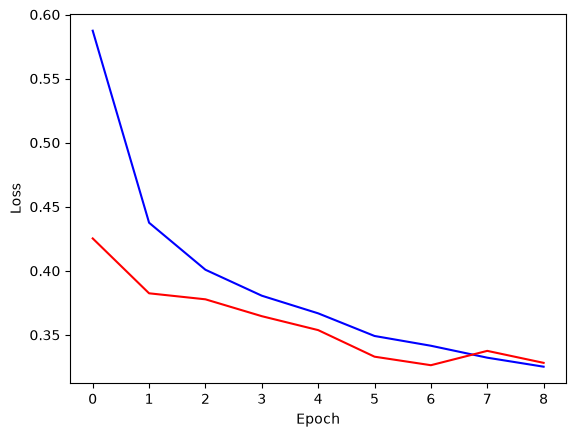

In [9]:
import matplotlib.pyplot as plt
# history의 시각화
plt.plot(history.history['loss'], color='blue')
plt.plot(history.history['val_loss'], color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [10]:
model_best = keras.models.load_model('data/best_model.keras')
model_best.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - accuracy: 0.8827 - loss: 0.3282


[0.3281933069229126, 0.8827499747276306]